In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

user = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST")
database = os.getenv("MYSQL_DATABASE")

engine = create_engine(
    f"mysql+mysqlconnector://{user}:{password}@{host}/{database}"
)

#### MONTHLY REVENUE TREND

In [197]:
query="""SELECT DATE_FORMAT(O.ORDER_PURCHASE_TIMESTAMP, "%Y-%m") AS MONTH, SUM(P.PAYMENT_VALUE) AS MONTHLY_REVENUE
FROM ORDERS AS O
JOIN PAYMENTS AS P
ON O.ORDER_ID=P.ORDER_ID
GROUP BY MONTH
ORDER BY MONTH"""

df=pd.read_sql(query,engine)

df["MONTHLY_REVENUE"]=df["MONTHLY_REVENUE"]/1000000




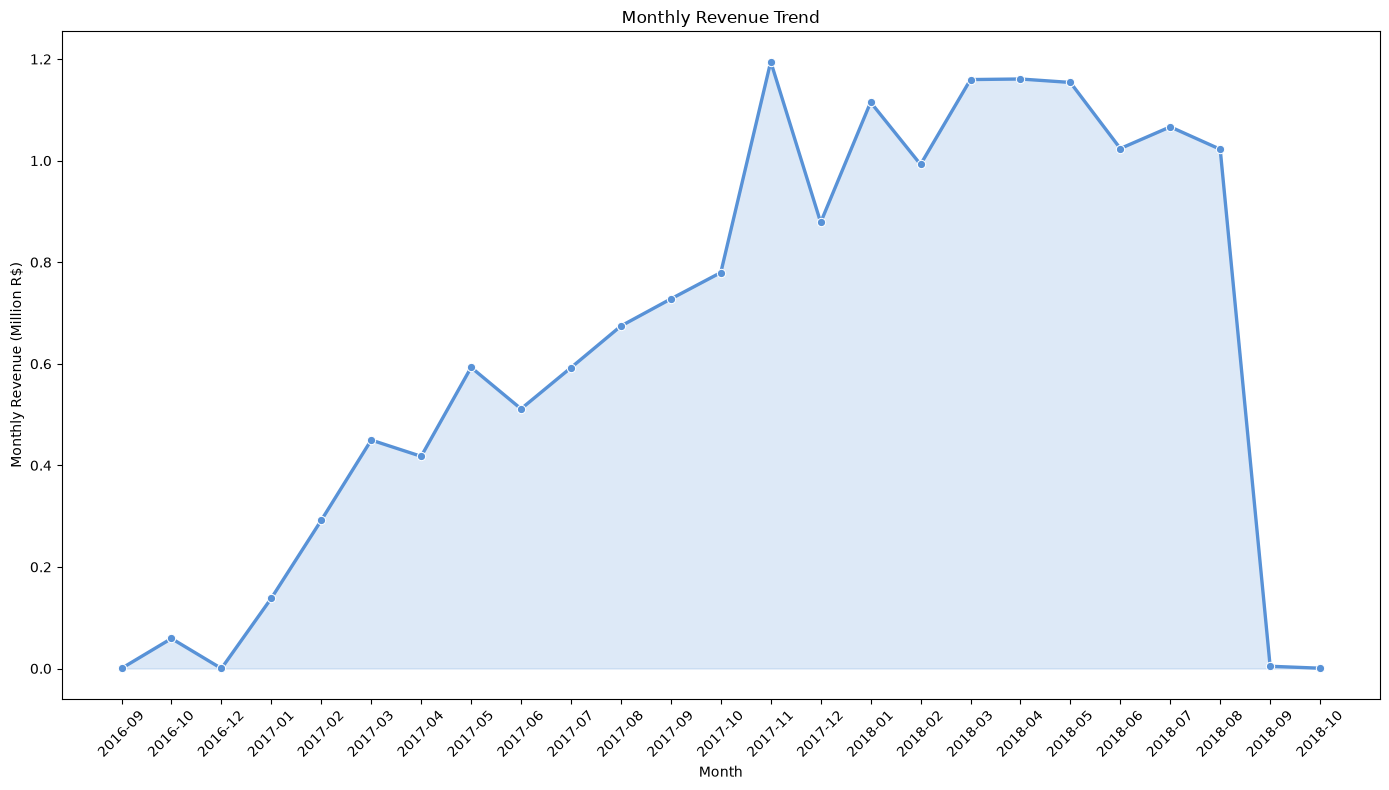

In [198]:
#CHART

plt.figure(figsize=(14,8))
sns.lineplot(x="MONTH", y="MONTHLY_REVENUE",data=df,
             marker="o",color="#5892d7",linewidth=2.4)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.ylabel("Monthly Revenue (Million R$)")

plt.fill_between(df["MONTH"],df["MONTHLY_REVENUE"],
                 color="#5892d7", alpha=0.2)

plt.tight_layout()


plt.savefig(
    "../images/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

##### INSIGHT

Identifies seasonal sales patterns, peak months, and periods of lower revenue.

#### TOP PRODUCT CATEGORIES

In [17]:
query="""SELECT PR.PRODUCT_CATEGORY_NAME,SUM(OI.PRICE) AS REVENUE_FROM_CATEGORY
FROM PRODUCTS AS PR
JOIN ORDER_ITEMS AS OI
ON PR.PRODUCT_ID=OI.PRODUCT_ID
GROUP BY PR.PRODUCT_CATEGORY_NAME
ORDER BY REVENUE_FROM_CATEGORY DESC
LIMIT 10"""

df=pd.read_sql(query,engine)

df["REVENUE_FROM_CATEGORY"]=df["REVENUE_FROM_CATEGORY"]/1000000
df["PRODUCT_CATEGORY_NAME"]=df["PRODUCT_CATEGORY_NAME"].str.title()
df["PRODUCT_CATEGORY_NAME"]=df["PRODUCT_CATEGORY_NAME"].str.replace("_"," ")



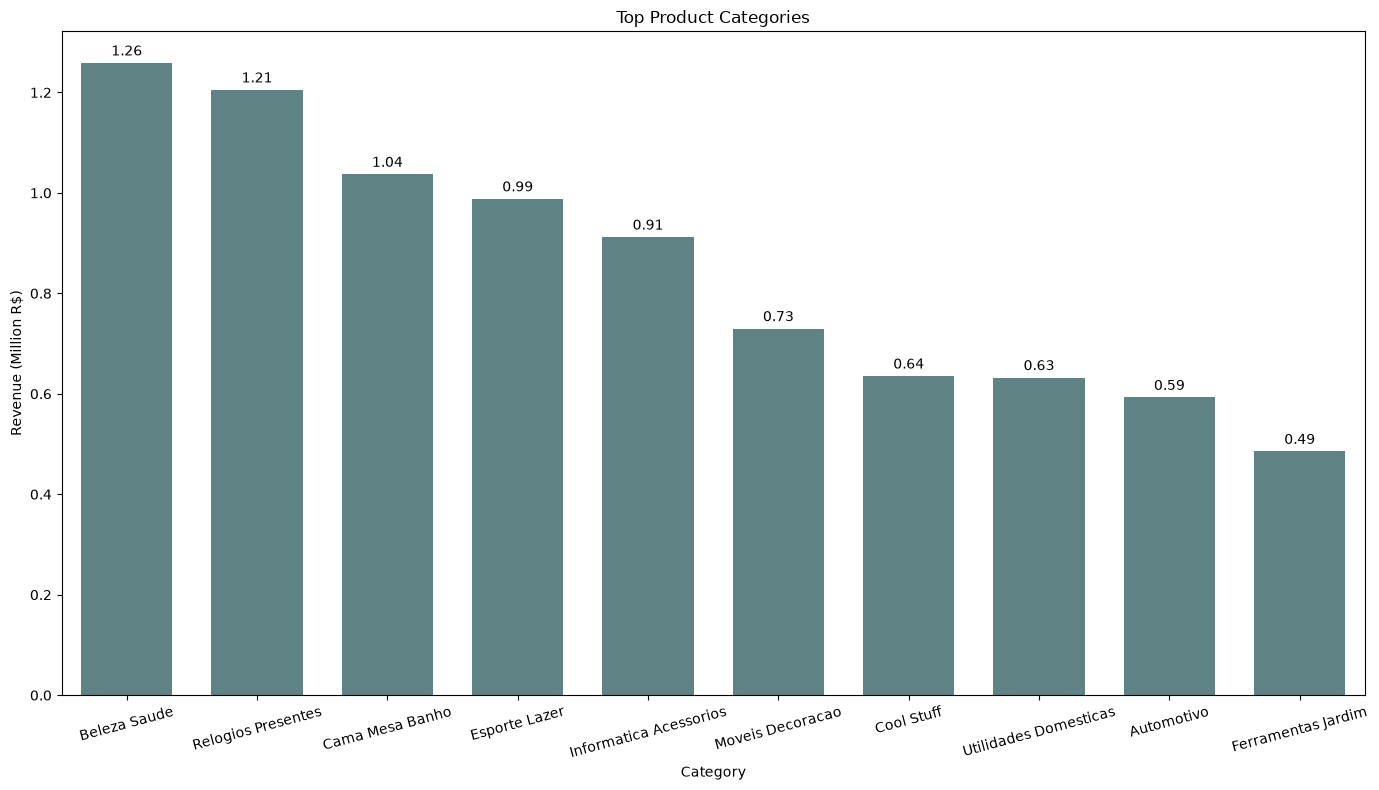

In [18]:
#CHART

plt.figure(figsize=(14,8))

ax=sns.barplot(x="PRODUCT_CATEGORY_NAME", y="REVENUE_FROM_CATEGORY",data=df,
            color="#59888A",width=0.7)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Revenue (Million R$)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../images/top_categories.png",
    dpi=300,
    bbox_inches="tight"
)



##### INSIGHT
Identifies the categories of the top selling products.

#### REVIEW SCORE DISTRIBUTION

In [193]:
query="""SELECT REVIEW_SCORE,COUNT(*) AS REVIEW_COUNT
FROM REVIEWS
GROUP BY REVIEW_SCORE
ORDER BY REVIEW_SCORE"""

df=pd.read_sql(query,engine)



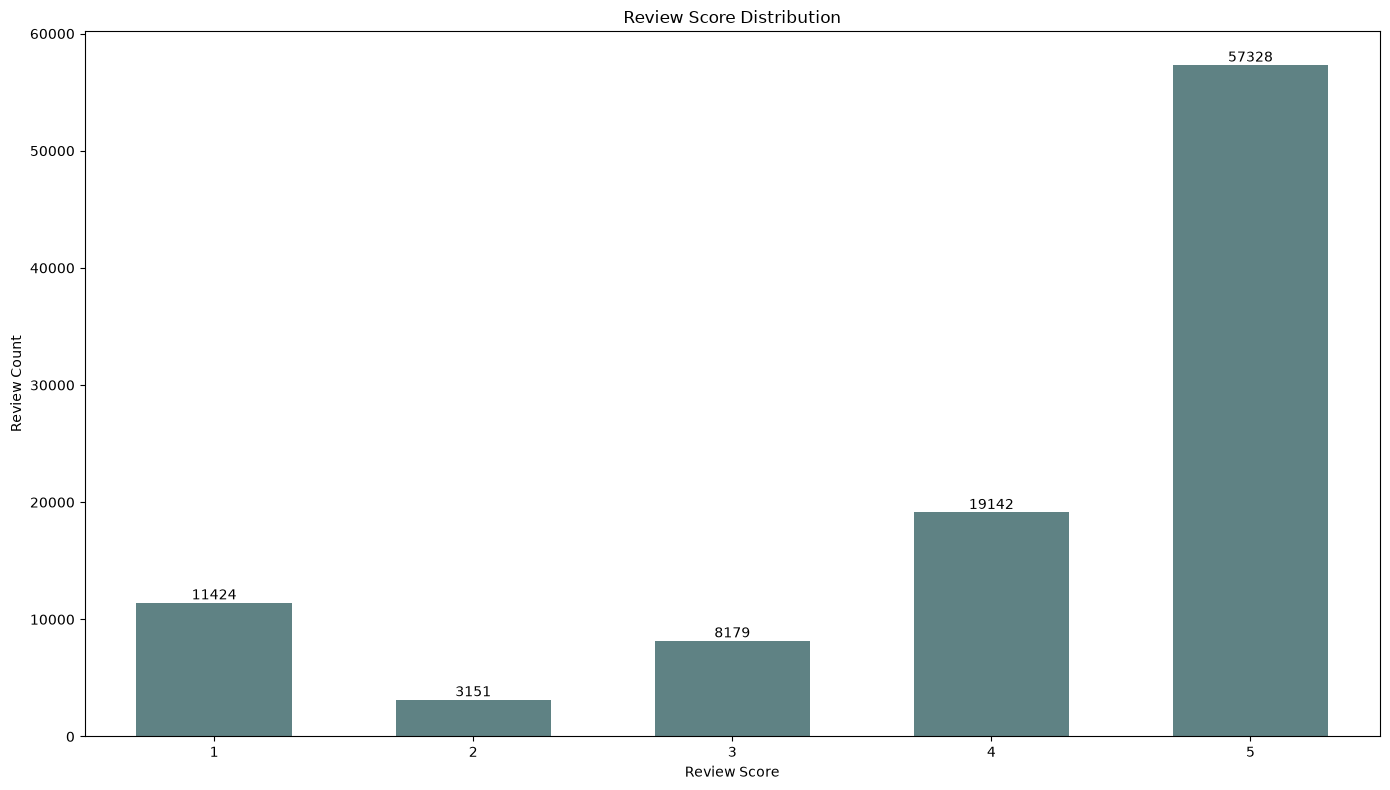

In [194]:
## CHART

plt.figure(figsize=(14,8))

ax=sns.barplot(x="REVIEW_SCORE",y="REVIEW_COUNT",data=df,width=0.6,color="#59888A")
for i in ax.containers:
    plt.bar_label(i)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Review Count")

plt.tight_layout()

plt.savefig(
    "../images/review_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

##### INSIGHT
Measures customer satisfaction and overall review patterns.

#### Revenue vs Review Score

In [14]:
query="""SELECT R.REVIEW_SCORE,SUM(P.PAYMENT_VALUE) AS REVENUE
FROM REVIEWS AS R
JOIN PAYMENTS AS P
ON R.ORDER_ID=P.ORDER_ID
GROUP BY R.REVIEW_SCORE
ORDER BY R.REVIEW_SCORE"""

df=pd.read_sql(query,engine)

df["REVENUE"]=df["REVENUE"]/1000000



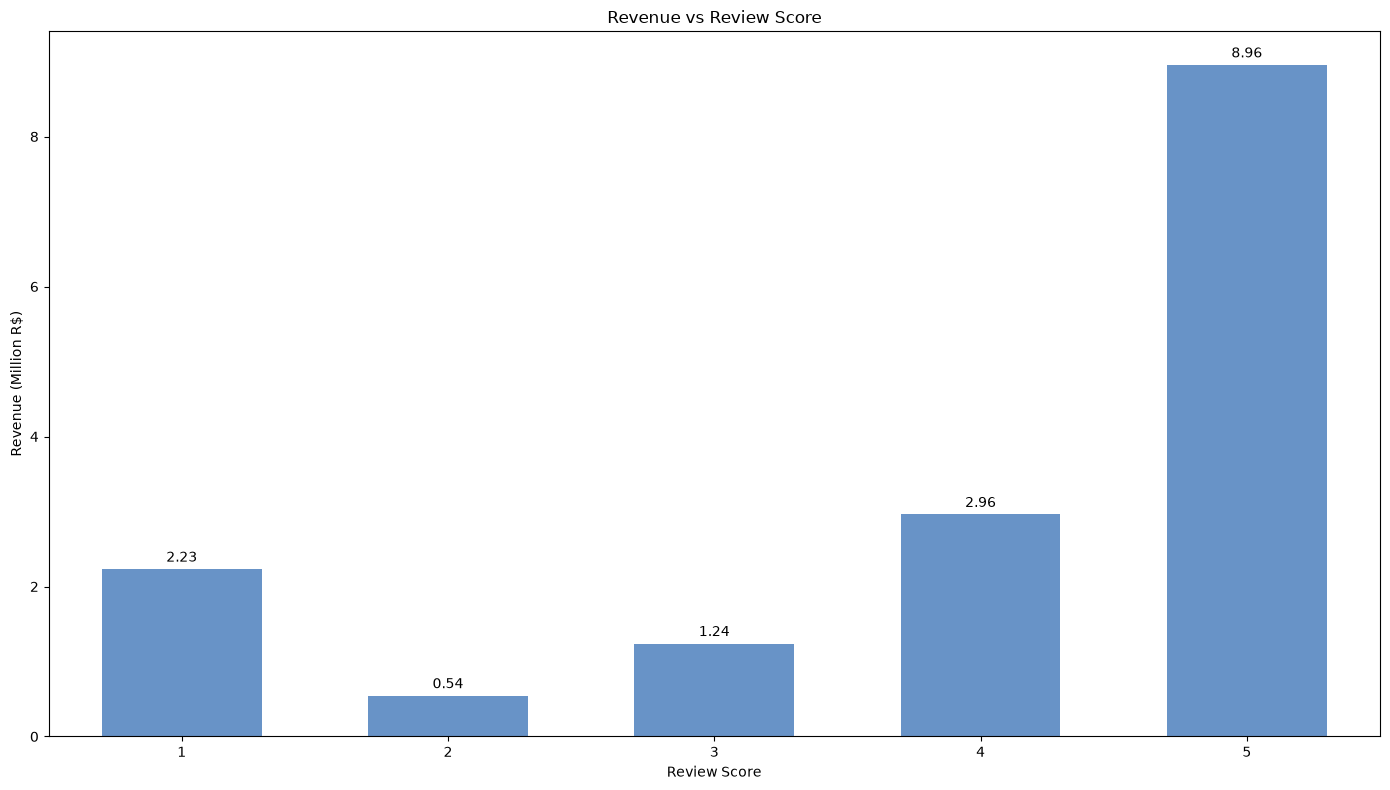

In [15]:
## CHART

plt.figure(figsize=(14,8))

ax=sns.barplot(x="REVIEW_SCORE",y="REVENUE",data=df,width=0.6,color="#5892d7")

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.title("Revenue vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Revenue (Million R$)")

plt.tight_layout()

plt.savefig(
    "../images/revenue_vs_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

##### INSIGHT
Evaluates whether higher-rated orders contribute more revenue.

#### CUSTOMER DISTRIBUTION BY STATE

In [189]:
query="""SELECT CUSTOMER_STATE,COUNT(*) AS NUMBER_OF_CUSTOMERS
FROM CUSTOMERS
GROUP BY CUSTOMER_STATE"""

df=pd.read_sql(query,engine)


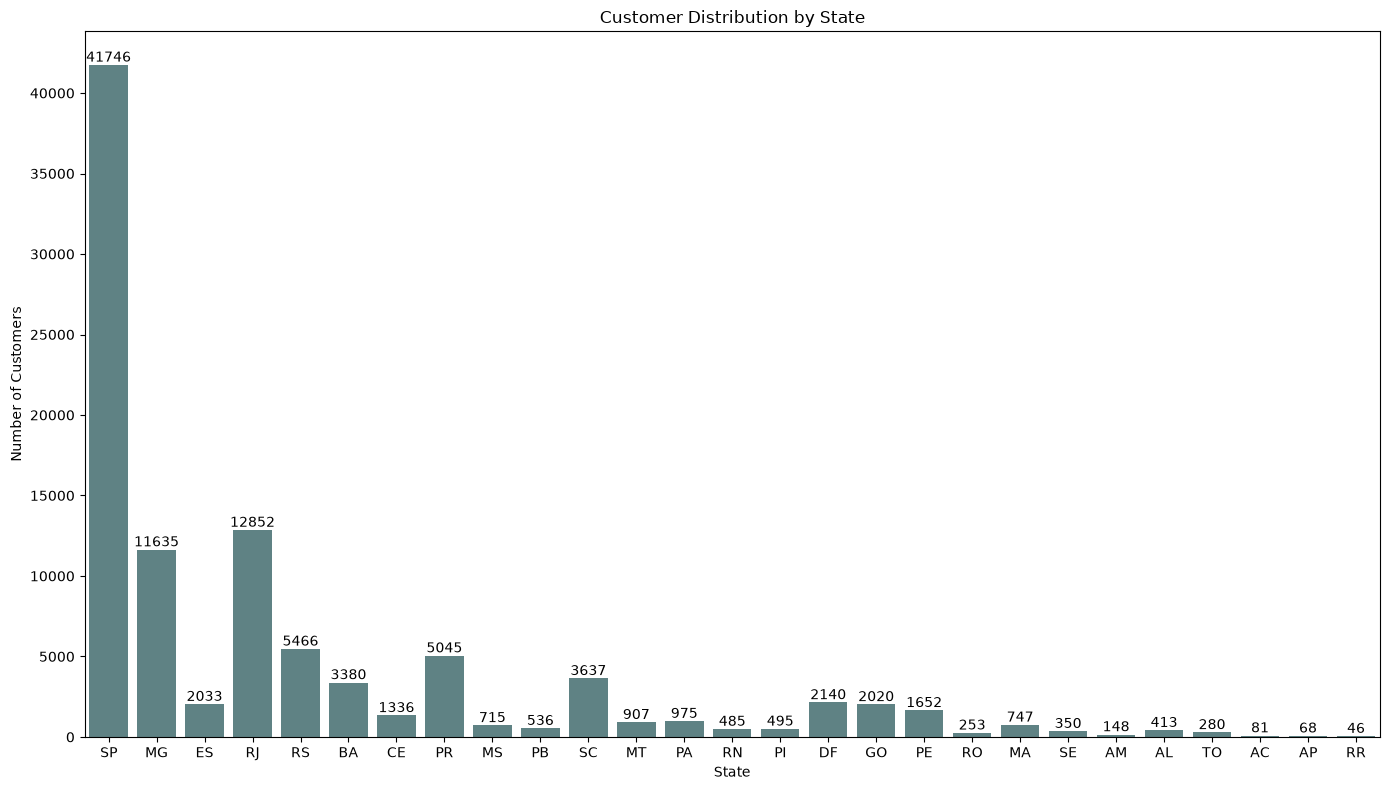

In [190]:
#CHART

plt.figure(figsize=(14,8))

ax=sns.barplot(x="CUSTOMER_STATE", y="NUMBER_OF_CUSTOMERS",data=df,width=0.8,color="#59888A")
for i in ax.containers:
    plt.bar_label(i)

plt.title("Customer Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../images/customer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

##### INSIGHT
Shows geographical distribution of the customer base.

#### TOP SELLERS BY REVENUE


In [12]:
query="""SELECT S.SELLER_ID,SUM(OI.PRICE) AS REVENUE_BY_SELLER
FROM SELLERS AS S
JOIN ORDER_ITEMS AS OI
ON S.SELLER_ID=OI.SELLER_ID
GROUP BY S.SELLER_ID
ORDER BY REVENUE_BY_SELLER DESC
LIMIT 10"""

df=pd.read_sql(query,engine)



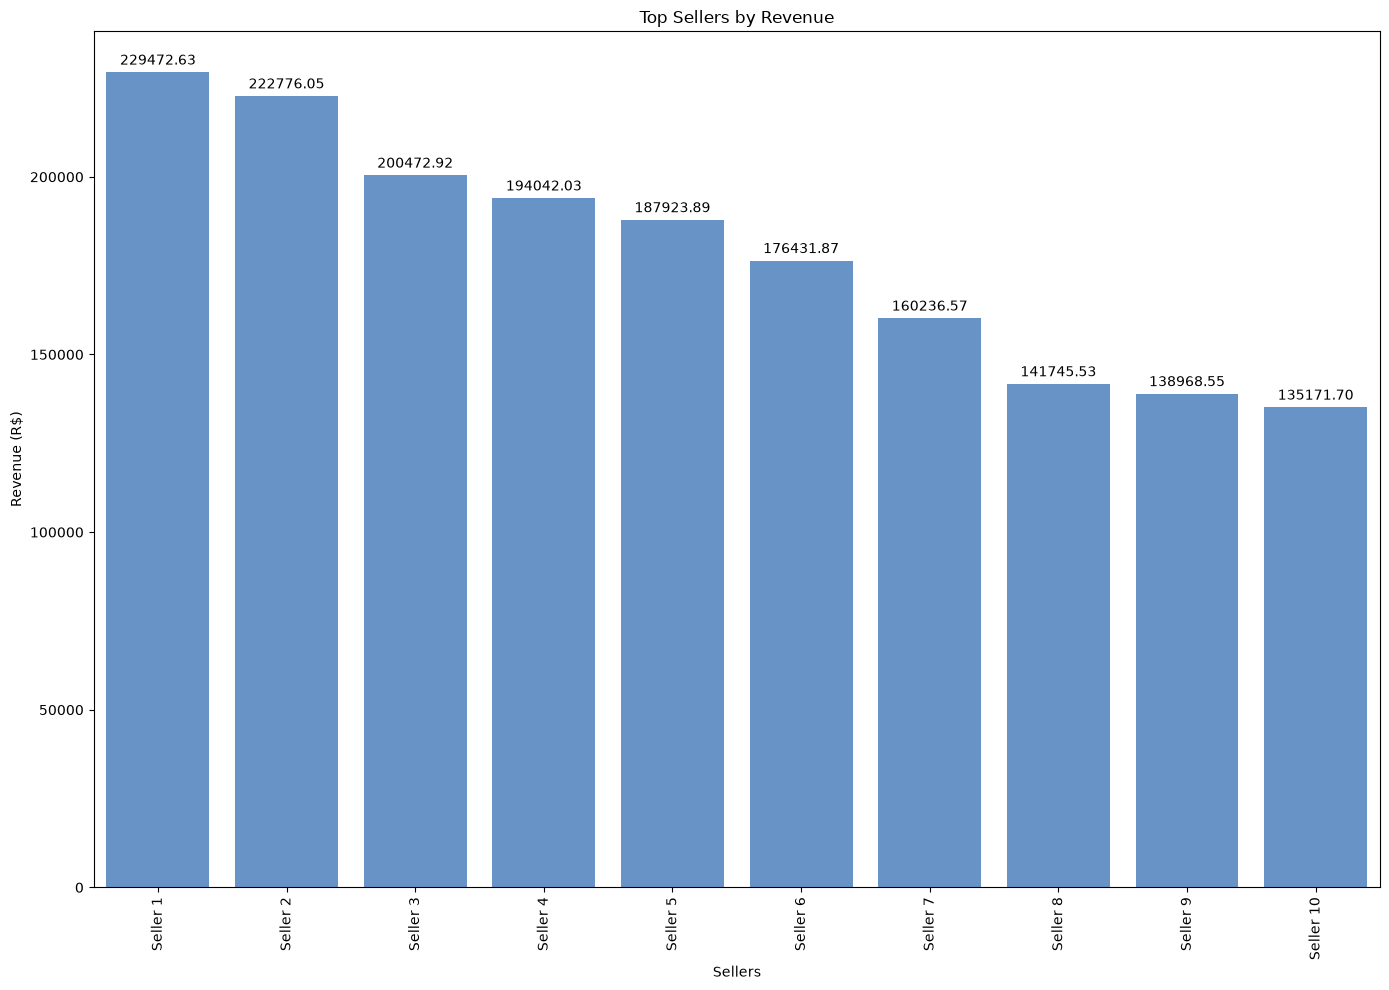

In [13]:
#CHART

plt.figure(figsize=(14,10))

df["Rank"] = [
    f"Seller {i}" for i in range(1, len(df)+1)
]


ax=sns.barplot(x="Rank", y="REVENUE_BY_SELLER",data=df,width=0.8,color="#5892d7")

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.title("Top Sellers by Revenue")
plt.xlabel("Sellers")
plt.xticks(rotation=90)
plt.ylabel("Revenue (R$)")

plt.tight_layout()

plt.savefig(
    "../images/seller_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

##### INSIGHT
Identifies the highest-performing sellers.

#### DELIVERY DELAY DISTRIBUTION

In [182]:
query="""SELECT DATEDIFF(ORDER_DELIVERED_CUSTOMER_DATE,
                ORDER_ESTIMATED_DELIVERY_DATE) AS DELAY_DAYS
FROM ORDERS
WHERE ORDER_DELIVERED_CUSTOMER_DATE IS NOT NULL"""


df=pd.read_sql(query,engine)



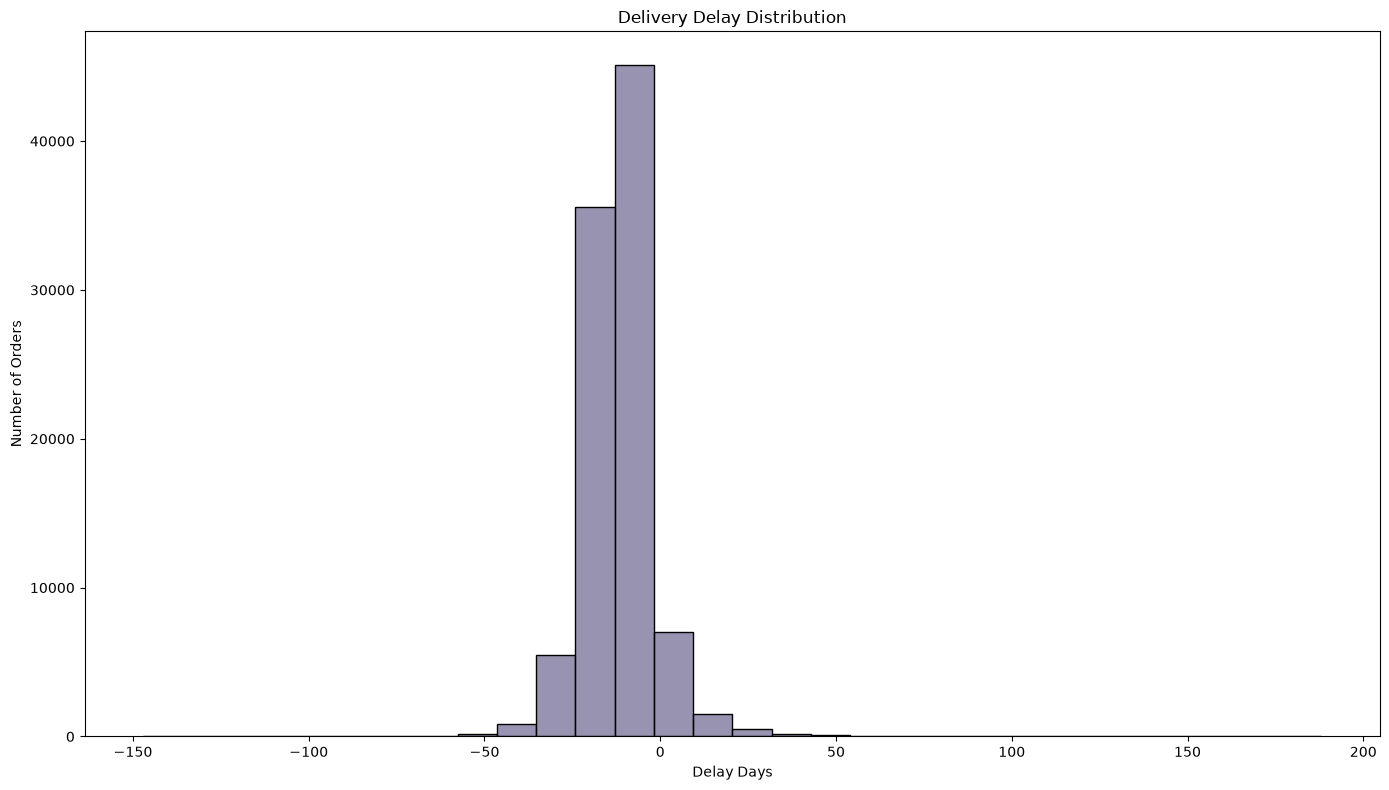

In [183]:
# CHART
plt.figure(figsize=(14,8))

sns.histplot(data=df["DELAY_DAYS"],bins=30,color="#766F97")

plt.title("Delivery Delay Distribution")
plt.xlabel("Delay Days")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../images/delivery_delay_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

##### INSIGHT
Shows whether most orders are delivered early, on time, or late, and identifies the frequency of delivery delays.

#### SLOWEST DELIVERY STATES

In [8]:
query="""SELECT C.CUSTOMER_STATE, AVG(DATEDIFF(O.ORDER_DELIVERED_CUSTOMER_DATE,O.ORDER_PURCHASE_TIMESTAMP))
AS NUMBER_OF_DELIVERY_DAYS 
FROM ORDERS AS O
JOIN CUSTOMERS AS C 
ON O.CUSTOMER_ID=C.CUSTOMER_ID
WHERE O.ORDER_DELIVERED_CUSTOMER_DATE IS NOT NULL
GROUP BY C.CUSTOMER_STATE
ORDER BY NUMBER_OF_DELIVERY_DAYS DESC
LIMIT 10"""

df=pd.read_sql(query,engine)



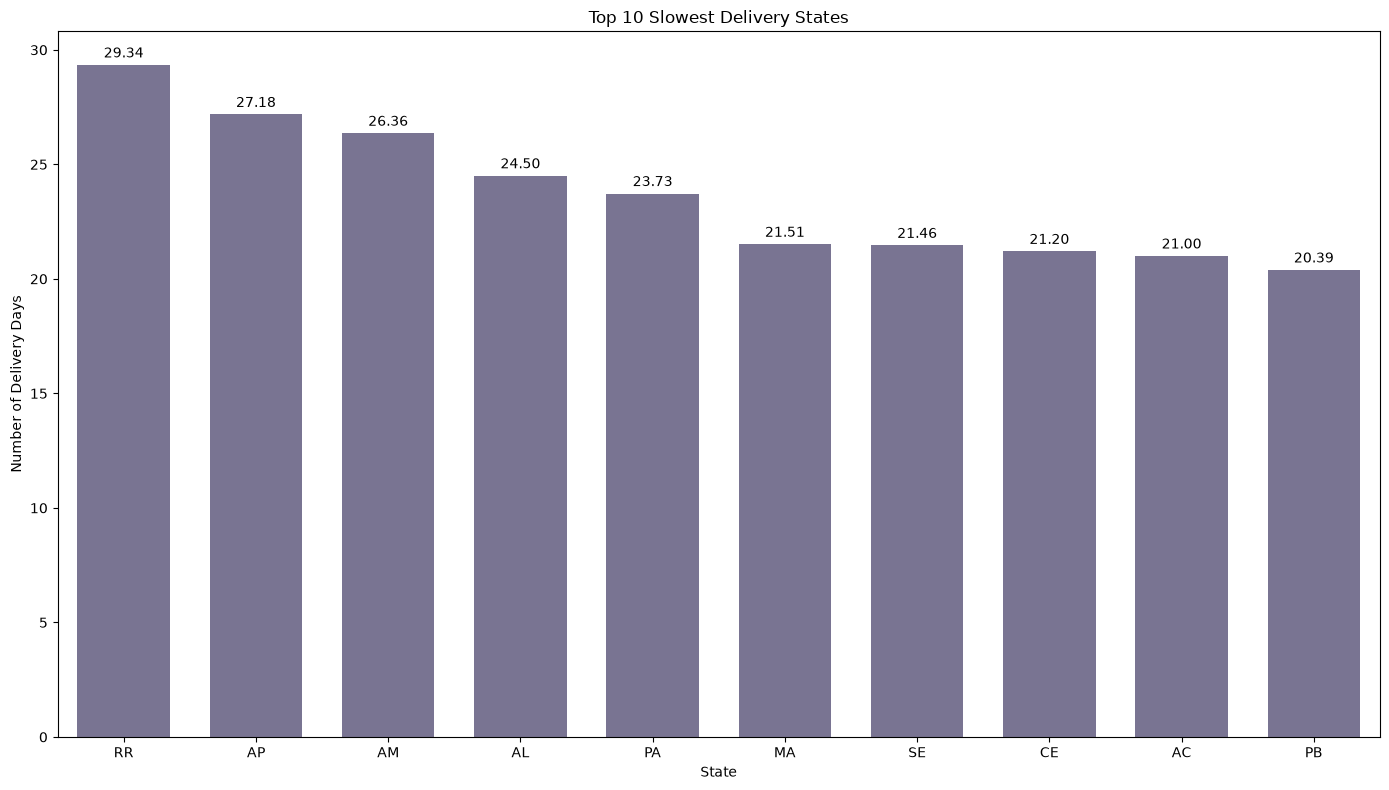

In [10]:
#CHART
plt.figure(figsize=(14,8))

ax=sns.barplot(x="CUSTOMER_STATE",y="NUMBER_OF_DELIVERY_DAYS",data=df,color="#766F97",
            width=0.7)


ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.title("Top 10 Slowest Delivery States")
plt.xlabel("State")
plt.ylabel("Number of Delivery Days")


plt.tight_layout()

plt.savefig(
    "../images/slowest_delivery_states.png",
    dpi=300,
    bbox_inches="tight"
)


#### INSIGHT
Helps detect regions where delivery performance needs improvement.